# Definición de modelo e implementación
Generación de caso piloto de PINN en MLP sencilla, y posteriormente aplicación en esquema

## Modelo Hibrido

### Definición del modelo

0. Llamado de modulos de interés

In [1]:
# Librerias de interés
import torch
import os

import sys

import pennylane as qml

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Import of source modules and utils needed
import src.trainer.schrodinger_train as wave_train

from src.utils.logger                   import Logging
from src.utils.plot_loss                import smooth_loss
from src.utils.plot_prediction          import plt_prediction

from src.nn.DVPDESolver                 import DVPDESolver
from src.nn.CVPDESolver                 import CVPDESolver
from src.nn.ClassicalSolver2            import ClassicalSolver2
from src.nn.pde                         import schrodinger_operator

from data.synthetic.schrodinger_dataset import exact_eigenstate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1. Definición de Parametros de entrenamiento

In [28]:
mode = "hybrid"
num_qubits = 5
output_dim = 2
input_dim = 2
hidden_dim = 30
num_quantum_layers = 1
cutoff_dim = 20
classic_network = [input_dim, hidden_dim, output_dim]

# Input parameters: Iterable
L = 5.0        # dominio espacial [0, L]
T = 0.1        # tiempo final
hbar = 1.0
mass = 1.0
n_level = 0    # nivel (usaremos n=1)
omega  = 1.0
example = 'ho'
potential_fn = 0

if example.lower() != 'box':
    potential_fn = f"lambda t, x : 0.5 * {mass} * ({omega}**2) * (x**2)"

# Equation parameters
eq_params = {
    'example' : example,             # Ejemplo a correr: "BOX", "HO" 
    'L': L,                          # dominio espacial [0, L]
    'T' : T,                         # tiempo final
    'hbar' : hbar,                   # Atomic coordinates = 1
    'mass' : mass,                   # Atomic coordinates = 1
    'n_level' : n_level,             # nivel del pozo (usaremos n=1)
    'omega'   : omega,               # Natural frequency
    'potential_fn' : potential_fn,   # potential function
}

args = {
    "batch_size": 64,
    "epochs": 2000, 
    "lr": 1E-3,
    "seed": 42,
    "print_every": 1,
    "log_path": "./results/models/checkpoints/schrodinger/qho",
    "input_dim": input_dim,
    "output_dim": output_dim,
    "num_qubits": num_qubits,
    "hidden_dim": hidden_dim,
    "num_quantum_layers": num_quantum_layers,
    "classic_network": classic_network,
    "q_ansatz": "sim_circ_19",  # options: "alternating_layer_tdcnot", "abbas" , farhi , sim_circ_13_half, sim_circ_13 , sim_circ_14_half, sim_circ_14 , sim_circ_15 ,sim_circ_19
    "mode": mode,
    "activation": "null",  # options: "null", "partial_measurement_half" , partial_measurement_x, tanh (Classical)
    "shots": 1,  # Analytical gradients enabled
    "problem": "schrodinger",
    "solver": "Classical",  # options : "CV", "Classical", "DV"
    "device": DEVICE,
    "method": "None",
    "cutoff_dim": cutoff_dim,  # num_qubits >= cutoff_dim
    "class": "CVNeuralNetwork2",  # options CVNeuralNetwork1, CVNeuralNetwork2, CVNeuralNetwork3
    "encoding": "angle",  # options : "ampiltude" , "angle" for DV , none for others
    "eq_params" : eq_params,
    "noise" : False,
}


2. Validación de componentes

In [29]:
log_path = args["log_path"]
logger = Logging(log_path)

In [30]:
if args["solver"] == "CV":
    model = CVPDESolver(args, logger, DEVICE)
    model.logger.print("Using CV Solver")
elif args["solver"] == "Classical":
    model = ClassicalSolver2(args, logger, DEVICE)
    model.logger.print("Using Classical Solver")
else:
    model = DVPDESolver(args, logger, DEVICE)
    model.logger.print("Using DV Solver")

model.logger.print(f"The settings used:")
for key, value in args.items():
    model.logger.print(f"{key} : {value}")

INFO:src.utils.logger:checkpoint path: self.log_path='./results/models/checkpoints/schrodinger/qho/2025-09-30_12-58-25-188950'
INFO:src.utils.logger:Using Classical Solver
INFO:src.utils.logger:The settings used:
INFO:src.utils.logger:batch_size : 64
INFO:src.utils.logger:epochs : 2000
INFO:src.utils.logger:lr : 0.001
INFO:src.utils.logger:seed : 42
INFO:src.utils.logger:print_every : 1
INFO:src.utils.logger:log_path : ./results/models/checkpoints/schrodinger/qho
INFO:src.utils.logger:input_dim : 2
INFO:src.utils.logger:output_dim : 2
INFO:src.utils.logger:num_qubits : 5
INFO:src.utils.logger:hidden_dim : 30
INFO:src.utils.logger:num_quantum_layers : 1
INFO:src.utils.logger:classic_network : [2, 30, 2]
INFO:src.utils.logger:q_ansatz : sim_circ_19
INFO:src.utils.logger:mode : hybrid
INFO:src.utils.logger:activation : null
INFO:src.utils.logger:shots : 1
INFO:src.utils.logger:problem : schrodinger
INFO:src.utils.logger:solver : Classical
INFO:src.utils.logger:device : cpu
INFO:src.utils.

In [31]:
# Definición de tipado para entrenamiento
DTYPE = torch.float32 
torch.set_default_dtype(DTYPE)
torch.manual_seed(0)

# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())
model.logger.print(f"Total number of parameters: {total_params}")

INFO:src.utils.logger:Total number of parameters: 2942


### Entrenamiento del modelo

0. Entrenamiento con parametros por defecto

In [32]:
wave_train.train(model)

INFO:src.utils.logger:It: 1, Loss: 7.873e-02, Loss_res: 2.663e+00,  Loss_bcs: 5.020e-02, Loss_ut_ics: 1.907e-01, L^2_error: 1.372402e+00, lr: 1.000e-03, Time: 1.61e-02


INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-30_12-58-25-188950/model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-30_12-58-25-188950/model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 5.107e-02, Loss_res: 1.217e+00,  Loss_bcs: 3.769e-02, Loss_ut_ics: 1.220e-01, L^2_error: 1.312419e+00, lr: 1.000e-03, Time: 5.80e-02
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-30_12-58-25-188950/model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-30_12-58-25-188950/model_weights.pth
INFO:src.utils.logger:It: 3, Loss: 3.561e-02, Loss_res: 5.576e-01,  Loss_bcs: 2.957e-02, Loss_ut_ics: 4.616e-02, L^2_error: 1.262338e+00, lr: 1.000e-03, Time: 8.16e-02
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-30_12-58-25-188950/model.pth
INFO:src.utils.logger:M

1. Métricas de entrenamiento

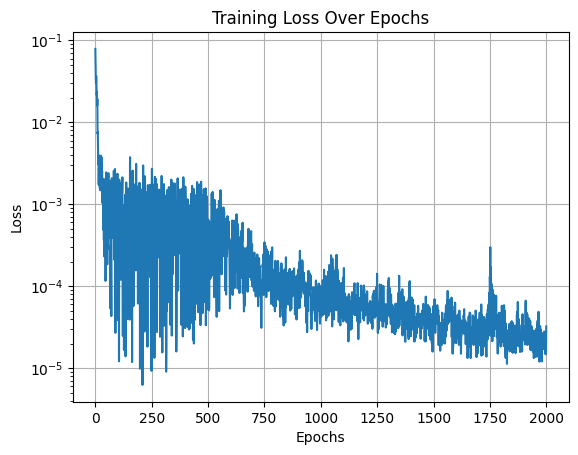

In [33]:
# Loss history plot 
plt.semilogy(range(len(model.loss_history)), model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

file_path = os.path.join(model.log_path, "loss_history.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

plt.close(
    "all",
)

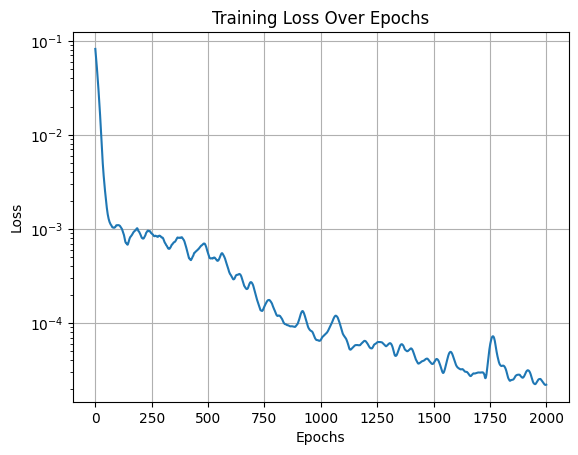

In [34]:
# Loss history plot 
plt.semilogy(range(len(model.loss_history)), smooth_loss(model.loss_history))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

file_path = os.path.join(model.log_path, "loss_history_smooth.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

plt.close(
    "all",
)

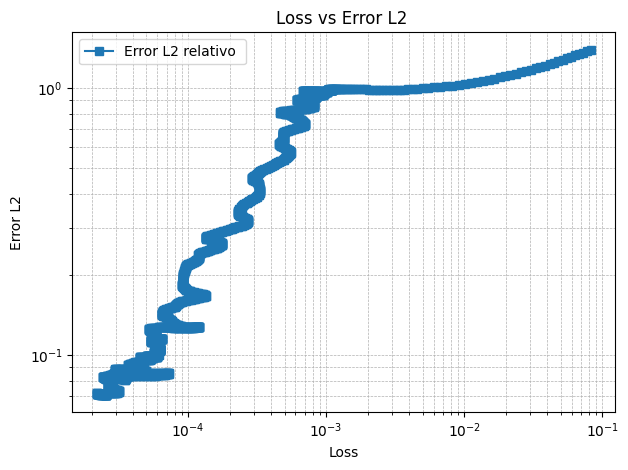

<Figure size 640x480 with 0 Axes>

In [ ]:
# Loss vs Error 


plt.figure()
plt.plot(smooth_loss(model.loss_history), smooth_loss(model.l2_rel_history), "-s", label="Error L2 relativo ")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Loss")
plt.ylabel("Error L2")
plt.title("Loss vs Error L2 ")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Saving of graph 
file_path = os.path.join(model.log_path, "LossVsError.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show(); plt.close("all")

### Cargado de modelos

0. Cargado de parametros de modelos

In [35]:
# Generación de dirección
# - Original model trainining it's ./results/models/checkpoints/schrodinger/qho/2025-09-16_19-49-40-397660 : 33 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-16_23-56-29-184043 : 240 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-17_05-32-12-177643 : Partial eval
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-18_23-15-25-067856 : 613 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_06-50-08-412171 : Partial eval
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_12-51-35-995760 : 726 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_15-21-51-366423 : Partial eval

#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_08-02-15-211102 : 266 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_11-42-54-648031 : Partial eval
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_15-24-52-373878 : 1000 epochs

model_dir = "./results/models/checkpoints/schrodinger/qho/2025-09-19_19-00-03-567204"

# Cargado de versiones de los modelos
model_path = os.path.join(model_dir, "model_weights.pth")

# Load the state dictionary into the model
model.load_state_dict(torch.load(model_path, weights_only=True))

# Set the model to evaluation mode (important for inference)
model.eval()

DVPDESolver(
  (preprocessor): Sequential(
    (0): Linear(in_features=2, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=5, bias=True)
  )
  (postprocessor): Sequential(
    (0): Linear(in_features=5, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=2, bias=True)
  )
  (activation): Tanh()
  (quantum_layer): DVQuantumLayer()
  (loss_fn): MSELoss()
)

### Pruebas de predicción

0. Definición de parametros

In [36]:
# Parametros físicos del dominio
L       = model.args['eq_params']['L']          # dominio espacial [0, L]
T       = model.args['eq_params']['T']          # tiempo final
hbar    = model.args['eq_params']['hbar'] 
mass    = model.args['eq_params']['mass']
n_level = model.args['eq_params']['n_level']    # nivel del pozo (usaremos n=1)

example = model.args['eq_params']['example']

# Definición por defecto de parametros
potential_fn = 0; omega = 1.0

# Cargado según ejemplos de uso
if model.args['eq_params']['example'].lower() == 'ho':             # Oscilador armonico

    potential_fn = eval(model.args['eq_params']['potential_fn'])   # Función de potencial
    omega        = model.args['eq_params']['omega']                # Frecuencia natural

potential_fn = eval(model.args['eq_params']['potential_fn'])
omega = 1.0; example = 'ho'

1. Generación de datos

In [37]:
# settings
number_of_points = 50

# mesh of t - x evaluation
# - Create mesh grid with float32
if example.lower() == 'ho':
    t = np.linspace(0, T, number_of_points, dtype=np.float32)[:, None]
    x = np.linspace(-L, L, number_of_points, dtype=np.float32)[:, None]
else:
    t = np.linspace(0, T, number_of_points, dtype=np.float32)[:, None]
    x = torch.linspace(0.0, L, number_of_points, device=DEVICE, dtype=DTYPE).unsqueeze(1)

t, x = np.meshgrid(t, x);

t = t.flatten()[:, None]
x = x.flatten()[:, None]

# - Generation of torch elements
t_eval = torch.from_numpy(t); x_eval = torch.from_numpy(x)

# - Generation of input argument
X_star = (
    torch.hstack(
        (torch.from_numpy(t.flatten()[:, None]), torch.from_numpy(x.flatten()[:, None]))
    )
    .to(DEVICE)
    .to(torch.float32)
)

X = X_star.cpu().detach().numpy()

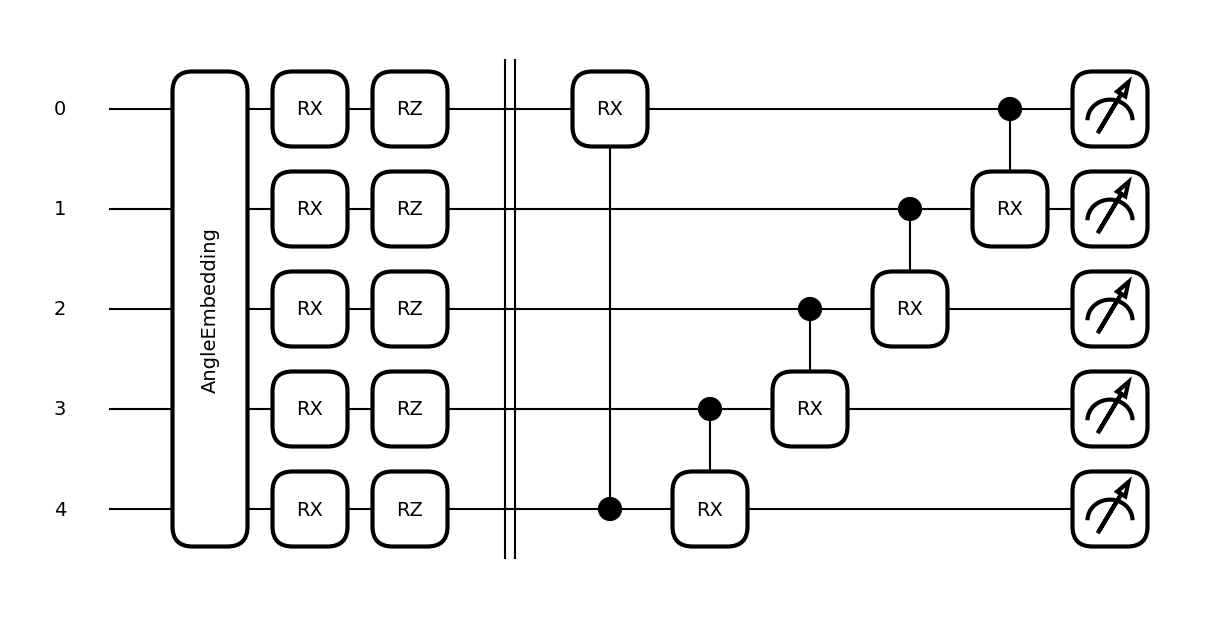

In [11]:
qml.draw_mpl(model.quantum_layer.circuit)(model.preprocessor(X_star[0, 0:2]));

In [38]:
# Predictions over values
with torch.no_grad():
    psi_pred = model(torch.cat((t_eval, x_eval), dim=1))
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]
    mod2_pred = (psi_r_pred**2 + psi_i_pred**2).squeeze(1).cpu().numpy()

    psi_r_true, psi_i_true, En = exact_eigenstate(n_level, t_eval, x_eval, L=L, mass=mass, hbar=hbar, omega=omega, example=example)
    mod2_true = (psi_r_true**2 + psi_i_true**2).squeeze(1).cpu().numpy()

2. Métricas de predicción

In [39]:
def magnitude_mean(y_pred_r, y_true_r, y_pred_i, y_true_i):

    # Squared differences for each value
    mse_r = (y_pred_r.cpu().detach().numpy() - y_true_r.cpu().detach().numpy())**2
    mse_i = (y_pred_i.cpu().detach().numpy() - y_true_i.cpu().detach().numpy())**2

    # Magnitude mse + norm
    mse = np.sqrt(mse_r + mse_i).mean()

    return mse

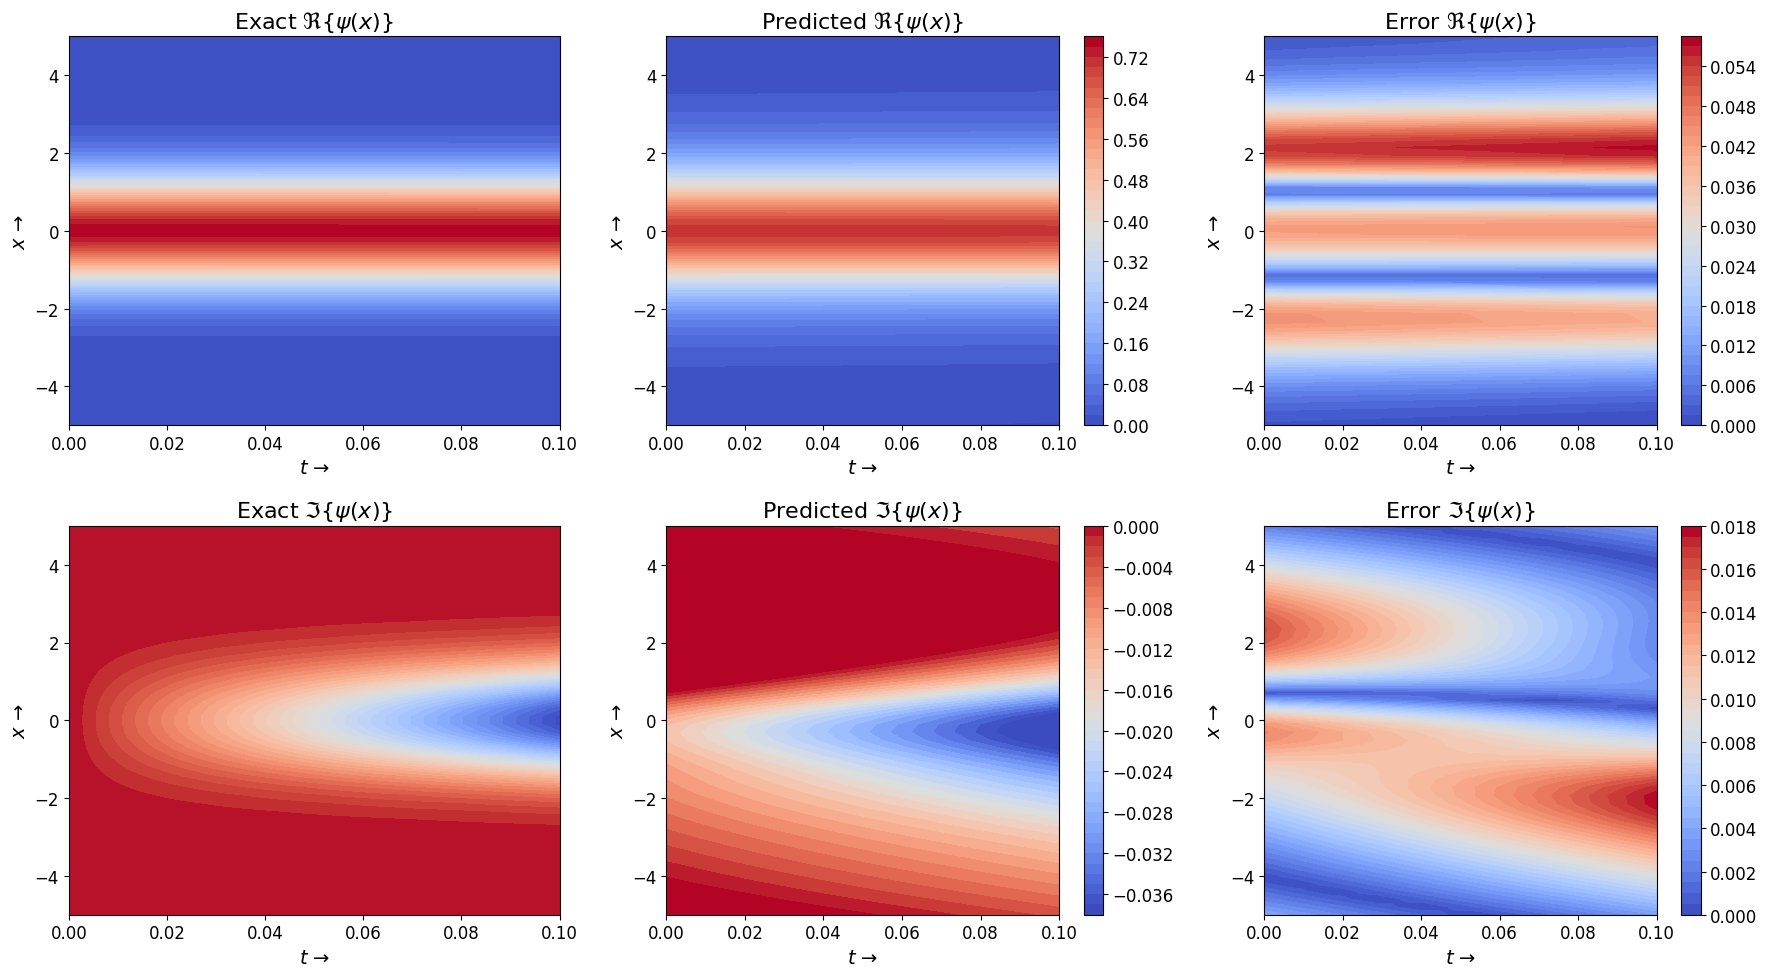

In [40]:
# Routine plots:
plt_prediction(
    logger,
    X,
    psi_r_true.cpu().detach().numpy(),
    psi_r_pred.cpu().detach().numpy(),
    psi_i_true.cpu().detach().numpy(),
    psi_i_pred.cpu().detach().numpy(),
)


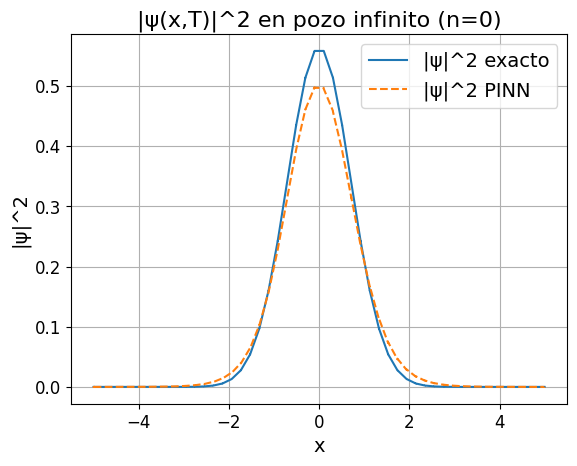

In [41]:
# Gráfico 1: |psi|^2 en t=T (PINN vs exacto)
plt.figure()
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_true, label="|ψ|^2 exacto")
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_pred, "--", label="|ψ|^2 PINN")
plt.title(f"|ψ(x,T)|^2 en pozo infinito (n={n_level})")
plt.xlabel("x")
plt.ylabel("|ψ|^2")
plt.legend()
plt.grid()

# Saving of solution comparison plot 
file_path = os.path.join(model.log_path, "solution_plot.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show(); plt.close("all")

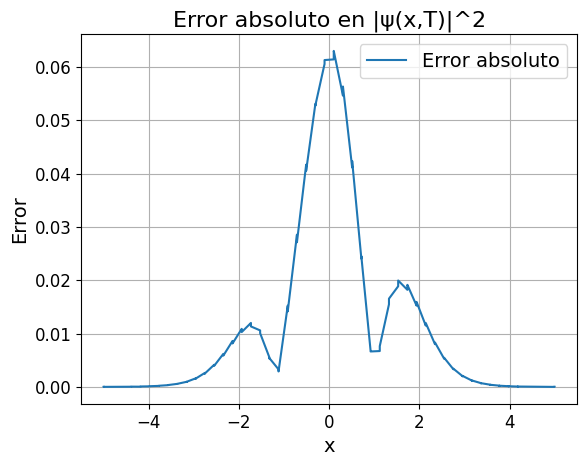

In [42]:
# Gráfico 2: error absoluto en |psi|^2
plt.figure()
abs_err = np.abs(mod2_pred - mod2_true)
plt.plot(x_eval.squeeze(1).cpu().numpy(), abs_err, label="Error absoluto")
plt.title("Error absoluto en |ψ(x,T)|^2")
plt.xlabel("x")
plt.ylabel("Error")
plt.legend()
plt.grid()

# Saving of solution comparison plot 
file_path = os.path.join(model.log_path, "error_plot.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show(); plt.close("all")